In [1]:

import tensorflow as tf
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.mnist.load_data()

2026-08-19 11:58:43.480307: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
x_train.shape

(60000, 28, 28)

In [3]:
x_test.shape

(10000, 28, 28)

In [5]:
##Preprocessing steps:

x_train=x_train.reshape(x_train.shape[0],28,28,1)  ## 1--  represent the gray scale image- no of channel -1
x_test=x_test.reshape(x_test.shape[0],28,28,1)
input_shape=(28,28,1)

In [6]:
x_train=x_train.astype('float32') ## For further calcultions like weights and gradients are in float
x_test=x_test.astype('float32')

In [11]:
x_train/=255 ## Normalising the values between 0 and 1(instaed of 0 and 255) for CNN for stable and efficient training
x_test/=255

In [12]:
##Procedure for model creation

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,Dropout,Flatten,MaxPooling2D
model=Sequential()
model.add(Conv2D(28,kernel_size=(3,3),input_shape=input_shape))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
##Convolutional ends and Neural Network starts
model.add(Dense(128,activation=tf.nn.relu))
model.add(Dropout(0.2))
model.add(Dense(10,activation=tf.nn.softmax))

In [13]:
##Model compile
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 28ms/step - accuracy: 0.9387 - loss: 0.2071
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9748 - loss: 0.0822 
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9819 - loss: 0.0569
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9860 - loss: 0.0435
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9890 - loss: 0.0357
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 22ms/step - accuracy: 0.9905 - loss: 0.0294
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9919 - loss: 0.0242
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9926 - loss: 0.0231
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9936 - loss: 0.0192
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 21ms/step - accuracy: 0.9938 - loss: 0.0177


In [14]:
# Evaluate CNN # to determine how well did my model perform?"

test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9841 - loss: 0.0709 


[0.07094915956258774, 0.9840999841690063]

In [17]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [19]:

##Predicting the lables# Testing
y_pred = model.predict(x_test)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step 


array([[6.01267286e-14, 7.45661262e-16, 4.30175440e-14, ...,
        9.99999940e-01, 1.06845636e-16, 1.12704523e-13],
       [3.60893433e-12, 7.56062324e-10, 9.99999940e-01, ...,
        3.40903813e-20, 7.80642426e-11, 7.49317441e-22],
       [1.19643503e-10, 9.99999702e-01, 2.00616038e-10, ...,
        6.77783447e-08, 1.85422966e-08, 2.22576254e-12],
       ...,
       [4.79280332e-23, 7.14784677e-13, 1.79106027e-18, ...,
        4.20981201e-11, 5.48070541e-13, 5.81842075e-10],
       [1.40188140e-19, 3.32716229e-17, 5.47452066e-19, ...,
        4.70707254e-14, 8.28137672e-07, 1.50197685e-17],
       [1.98106607e-16, 2.44405835e-18, 2.70356738e-14, ...,
        2.03298705e-24, 7.89366131e-13, 2.37366796e-16]], dtype=float32)

In [21]:
import numpy as np
# Convert to class labels
y_pred = np.argmax(y_pred, axis=1)
y_pred


array([7, 2, 1, ..., 4, 5, 6])

In [23]:
# Actual labels
#y_true = y_test
#If y_test is one-hot encoded:
#y_true = np.argmax(y_test, axis=1)

# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print(cm)



[[ 975    1    0    0    1    0    1    1    1    0]
 [   0 1127    3    1    0    0    2    0    1    1]
 [   3    1 1014    0    2    0    4    5    1    2]
 [   2    0    2  996    0    2    0    4    3    1]
 [   0    0    2    0  969    0    1    0    1    9]
 [   2    0    1    6    0  879    2    0    2    0]
 [   6    2    0    0    5    1  942    0    2    0]
 [   1    2   11    0    1    0    0 1002    1   10]
 [   7    0    2    2    2    0    2    3  951    5]
 [   2    1    1    2    7    4    0    4    2  986]]


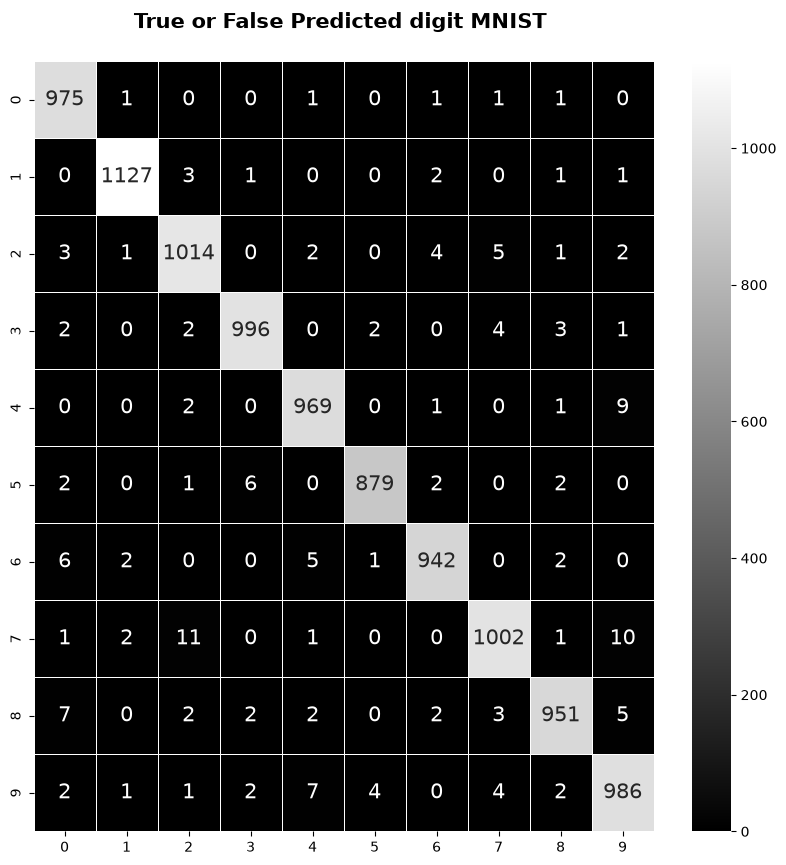

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
##plt.style.use('seaborn-deep')
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(cm,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False Predicted digit MNIST \n',fontweight='bold',fontsize=15)
plt.show()

In [29]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.99      0.99      0.99      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.99      0.99       892
           6       0.99      0.98      0.99       958
           7       0.98      0.97      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.97      0.98      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [49]:
#Before submitting , validate the model for single input

y_predict_single = model.predict(x_test[[1]])
y_predict_single=np.argmax(y_predict_single,axis=1)
y_predict_single

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


array([2])

In [50]:
y_predict_single=y_predict_single[0]
y_predict_single

2

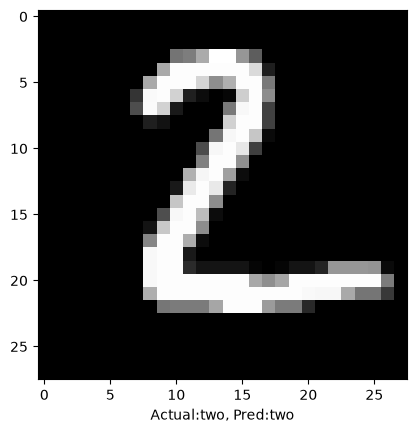

In [52]:
#Names of numbers in the dataset in order
col_names=['zero','one','two','three','four','five','six','seven','eight','nine']

##Visualising the digits
plt.imshow(x_test[1].reshape(28,28),cmap='gray')
plt.xlabel("Actual:{}, Pred:{}".format(col_names[y_test[1]],col_names[y_predict_single]))
plt.show()